In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
M_N = 28
M_s = 18
R_N = 8.314 / M_N
R_s = 8.314 / M_s

P_0 = 100 # kPa
T_0 = 20 # C
T_0 += 273.15 # K
V_t = 0.8 # m3
alpha_0 = 0.2

m_N = None # kg
m_s = 1000 # kg

In [33]:
# physical properties funciton
def vapor_pressure(T, A, B, C):
    A_kPa = A * np.log(10) + np.log(101.325 / 760)
    ln_P_kPa = A_kPa - B * np.log(10) / (C + T - 273)
    _P_kPa = np.exp(ln_P_kPa)
    return _P_kPa

def water_vp(T):
    if T - 273 <= 100:
        A, B, C = 8.07131, 1730.63, 233.426
    else:
        A, B, C = 8.14019, 1810.94, 244.485

    _w_vp = vapor_pressure(T, A, B, C)
    
    return _w_vp

def spec_vol(T):
    T_c = 647.095
    tau = 1 - T / T_c
    B = [17.863, 58.606, -95.396, 213.89, -141.26]
    _density_kmol_m3 = B[0] + B[1] * tau ** (0.35) + B[2] * tau ** (2/3) + B[3] * tau + B[4] * tau ** (4/3)
    _density_kg_m3 = _density_kmol_m3 * 18
    _spec_vol = 1 / _density_kg_m3
    return _spec_vol

In [34]:
if m_N == None:
    m_N = alpha_0 * m_s * spec_vol(T_0) * P_0 / ((1 - alpha_0) * R_N * T_0)
else:
    alpha_0 = 1 / ( 1 + m_s * spec_vol(T_0) * P_0 / ( m_N * R_N * T_0 ) )

In [35]:
# vapor mass
def m_v(P, T, vapor_pressure_func=water_vp):
    global m_N
    y_v = vapor_pressure_func(T) / P
    mf_v = y_v * M_s / ( M_N + ( M_s - M_N ) * y_v )
    _m_v = (1 / ( 1 - mf_v ) - 1 ) * m_N
    return _m_v

In [36]:
# derivatives
def derivative_T(f, T):
    _h = 0.01
    _d = (f(T+_h) - f(T-_h)) / (2 * _h)
    return _d

def dmv_dT(P, T):
    global m_N
    _h = 0.01
    _d = (m_v(P, T+_h) - m_v(P, T-_h)) / (2 * _h)
    return _d

def dmv_dP(P, T):
    global m_N
    _h = 0.01
    _d = (m_v(P+_h, T) - m_v(P-_h, T)) / (2 * _h)
    return _d

def dv_dT(T):
    _dv_dT = derivative_T(spec_vol, T)
    return _dv_dT

In [37]:
# liquid volume derivatives
def dV_l_dT(P, T):

    _dV_l_dT = (m_s - m_v(P, T)) * dv_dT(T) - spec_vol(T) * dmv_dT(P, T)

    return _dV_l_dT

def dV_l_dP(P, T):

    _dV_l_dP = -spec_vol(T) * dmv_dP(P, T)

    return _dV_l_dP

# vapor volume derivatives
def dV_v_dT(P, T):

    _dV_v_dT = R_s / P * ( m_v(P, T) + T * dmv_dT(P, T) )

    return _dV_v_dT

def dV_v_dP(P, T):

    _dV_v_dT = R_s * T / P * ( dmv_dP(P, T) - m_v(P, T) / P )

    return _dV_v_dT

# nitrogen volume derivatives
def dV_N_dT(P):

    _dV_N_dT = m_N * R_N / P

    return _dV_N_dT

def dV_N_dP(P, T):

    _dV_N_dP = -m_N * R_N * T / P ** 2

    return _dV_N_dP

In [38]:
# total derivatives
def dV_dT(P, T):

    _dV_dT = dV_l_dT(P, T) + dV_v_dT(P, T) + dV_N_dT(P)

    return _dV_dT

def dV_dP(P, T):

    _dV_dP = dV_l_dP(P, T) + dV_v_dP(P, T) + dV_N_dP(P, T)

    return _dV_dP

In [39]:
def temperature(T_0, P_0, P_e, no_of_steps):
    T_0_K = T_0 + 273.15
    
    DP = (P_e - P_0) / no_of_steps
    P = [P_0]
    T = [T_0_K]
    mv_list = [m_v(P_0, T_0_K)]
    F_list = [-dV_dP(P_0, T_0_K) / dV_dT(P_0, T_0_K)]
    
    for i in range(no_of_steps):
        
        P_i = P_0 + (i + 1) * DP
        T_i = T[i]
        F = -dV_dP(P_i, T_i) / dV_dT(P_i, T_i)
        mv_i = m_v(P_i, T_i)
        if mv_i > m_s:
            mv_i = m_s
        mv_list.append(mv_i)
        F_list.append(F)
        P.append(P_i)
        T.append(T_i + F * DP)
        
    T = np.array(T) - 273.15
    return np.c_[P, T, mv_list, F_list]

In [40]:
pt_n = temperature(T_0-273, P_0, 700, 100)

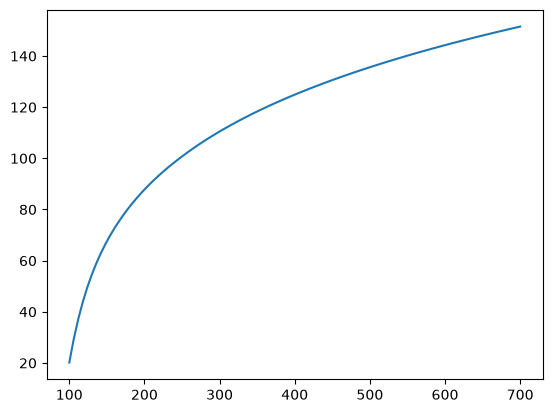

In [46]:
plt.plot(pt_n[:, 0], pt_n[:,1])

In [42]:
alpha_n = 1 - spec_vol(pt_n[:, 1]+273.15) / spec_vol(T_0)*(1 - alpha_0)

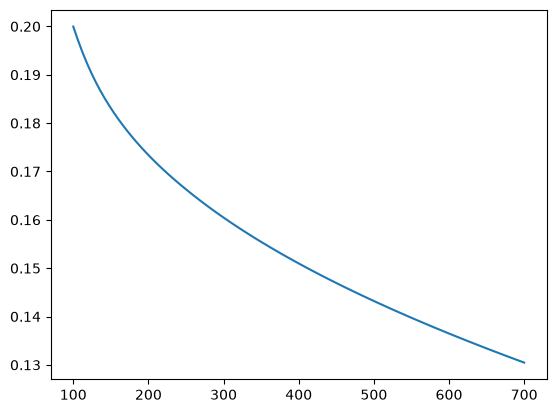

In [47]:
plt.plot(pt_n[:, 0], alpha_n)

In [44]:
a = pd.DataFrame(pt_n, columns=['pressure', 'temperature', 'm_v', 'F'])
a.loc[:, 'liquid_level'] = spec_vol(a['temperature']+273.15) / spec_vol(T_0)*(1 - alpha_0)
a.loc[:, 'p_pisg'] = a['pressure']/100*14.50377-14.21

In [45]:
a

,pressure,temperature,m_v,F,liquid_level,p_pisg
0,100.0,20.150000,0.004508,1.632738,0.800042,0.293770
1,106.0,29.384395,0.004247,1.539066,0.802748,1.163996
2,112.0,37.204875,0.007082,1.303413,0.805251,2.034222
3,118.0,43.857029,0.010603,1.108692,0.807536,2.904449
4,124.0,49.576896,0.014657,0.953311,0.809621,3.774675
...,...,...,...,...,...,...
96,676.0,149.864257,0.415638,0.069941,0.868136,83.835485
97,682.0,150.280190,0.418918,0.069322,0.868487,84.705711
98,688.0,150.692483,0.422180,0.068716,0.868835,85.575938
99,694.0,151.101206,0.425422,0.068120,0.869181,86.446164
